# Step 1 – Load & Explore Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\קונפינו\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [3]:
import os

csv_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


missing values

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [11]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

<div dir="rtl" style="text-align: right;">

למה למלא ב־0?

כי אם לקוח נמצא בחברה 0 חודשים, הגיוני ש־TotalCharges שלו יהיה 0. כלומר:

- tenure = 0
- MonthlyCharges = יש מחיר חודשי מוגדר
- TotalCharges = עדיין לא שולם סכום מצטבר

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
# Check rows with missing TotalCharges
missing_total_charges = df[df["TotalCharges"].isnull()]

missing_total_charges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn


In [14]:
# Fill missing TotalCharges values with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Check again for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

בדיקת התפלגות משתנה המטרה — Churn

In [16]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


<div dir="rtl" style="text-align: right;">

גרף להתפלגות Churn


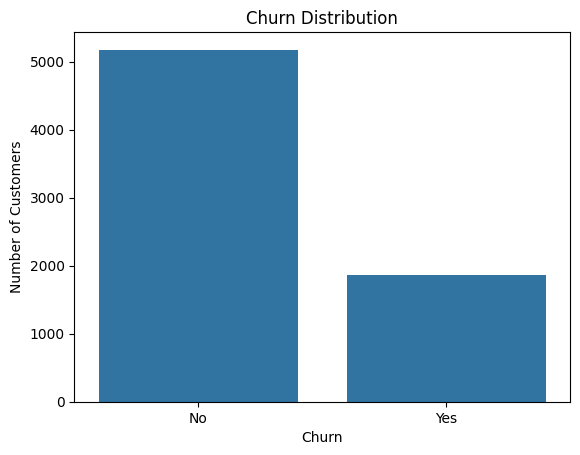

In [17]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

<div dir="rtl" style="text-align: right;">

אם רוב הלקוחות הם No, אז מודל שיחזה תמיד No יכול לקבל Accuracy יחסית גבוהה, אבל הוא לא באמת יעזור לחברה לזהות לקוחות שעומדים לעזוב.

<div dir="rtl" style="text-align: right;">

זיהוי עמודות מספריות וקטגוריאליות

In [18]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


<div dir="rtl" style="text-align: right;">

בדיקת התפלגות של עמודות מספריות

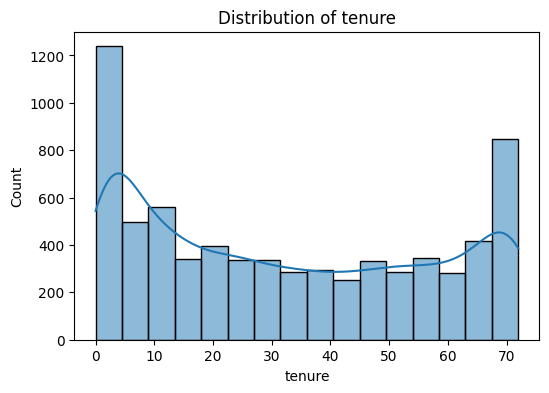

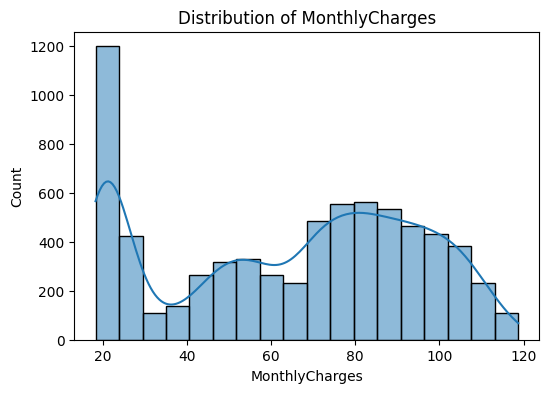

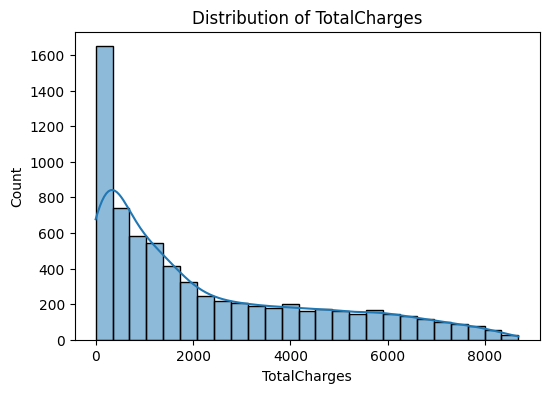

In [19]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

<div dir="rtl" style="text-align: right;">


| Feature        | מה הוא אומר                        |
| -------------- | ----------------------------------  |
| tenure         | כמה חודשים הלקוח נמצא בחברה        |
| MonthlyCharges | כמה הלקוח משלם בכל חודש            |
| TotalCharges   | כמה הלקוח שילם בסך הכול לאורך הזמן |


<div dir="rtl" style="text-align: right;">

בדיקת קשר ראשוני בין Churn למשתנים מספריים


- האם לקוחות עם tenure נמוך נוטים יותר לנטוש?
- האם לקוחות עם MonthlyCharges גבוהים נוטים יותר לנטוש?

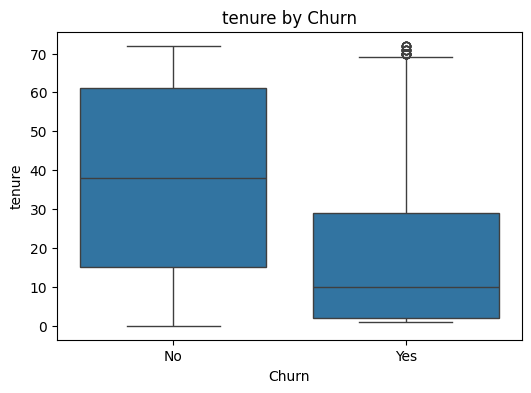

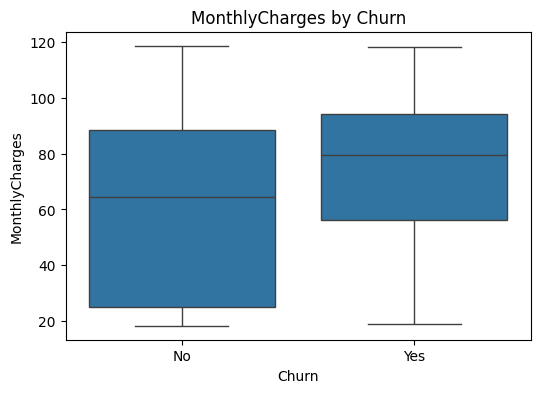

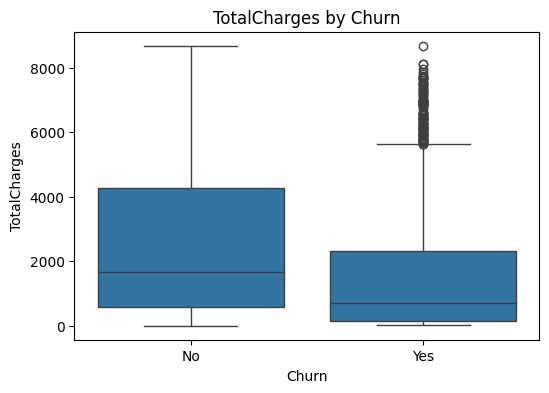

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

<div dir="rtl" style="text-align: right;">

בדיקת משתנים קטגוריאליים מרכזיים

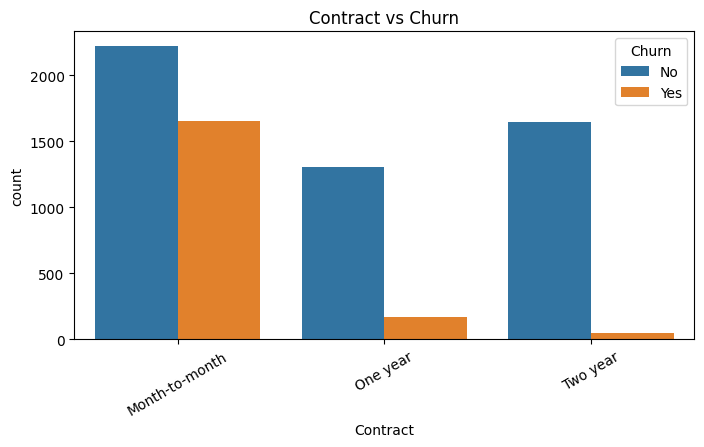

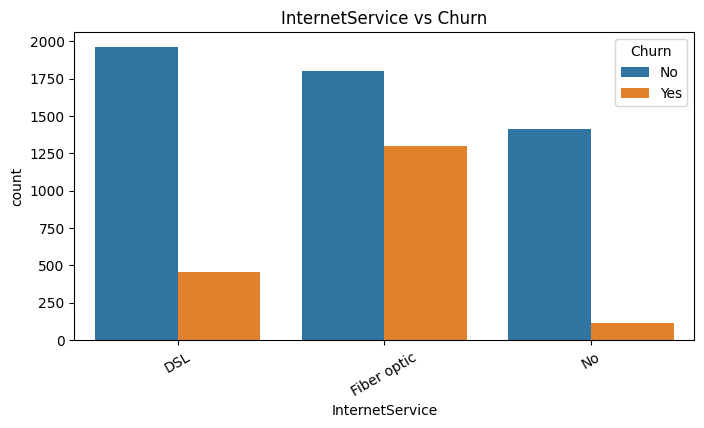

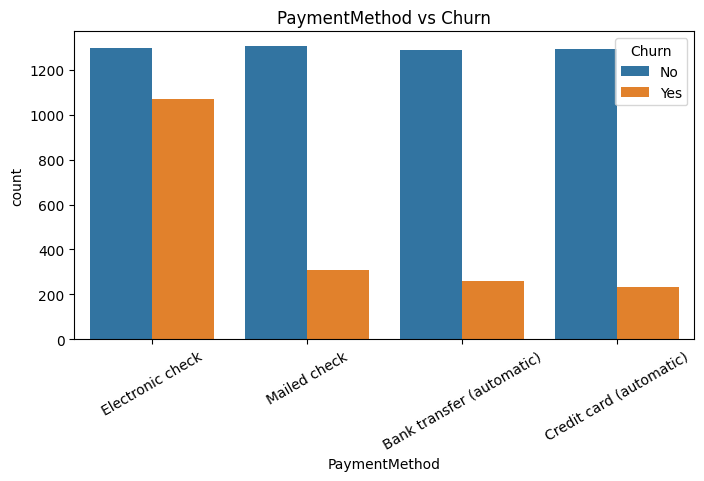

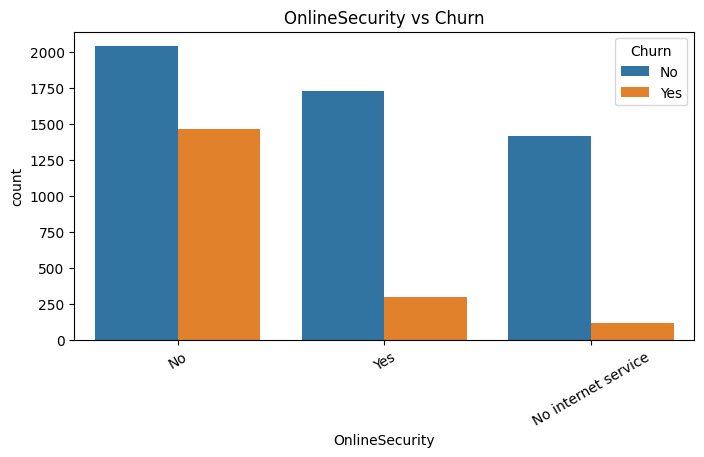

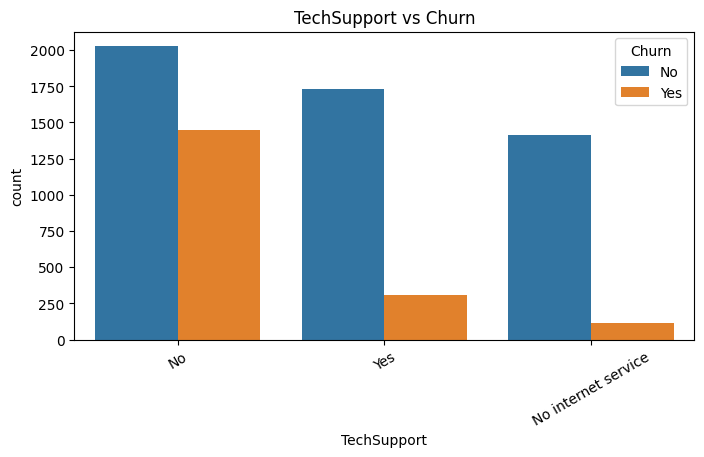

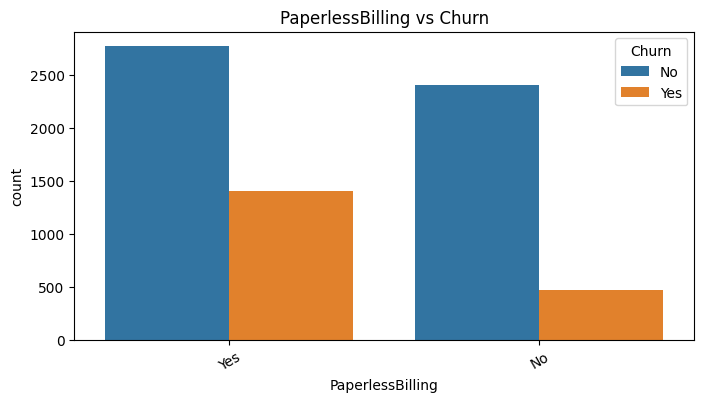

In [21]:
important_categorical = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling"
]

for col in important_categorical:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.show()

# step 2 - data preparation

<div dir="rtl" style="text-align: right;">
שלב הכנת הנתונים למודלים

- הגדרת x y
- חלוקה לסט אימון וסט מבחן
- לעשות הכנה של ה data

<div dir="rtl" style="text-align: right;">
יצירת עותק לדאטה

In [22]:
df_model = df.copy()

<div dir="rtl" style="text-align: right;">
המרת churn ל 0/1

In [23]:
df_model["Churn"]= df_model["Churn"].map({"Yes": 1, "No": 0})
df_model["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

<div dir="rtl" style="text-align: right;">
הגדרת x y

- customerID זו עמודת מזהה ולכן לא נשתמש בה כ feature
- churn זה מה שאנחנו רוצים לחזות ולכן זה יהיה y

In [24]:
x = df_model.drop(["customerID", "Churn"], axis=1)
y = df_model["Churn"]

train/ test split
<div dir="rtl" style="text-align: right;">
משתמשים ב stratify=y כי יש לנו חוסר איזון במחלקות 

- 73 אחוז לא
- 27 אחוז כן 

אנחנו רוצים שגם באימון וגם במבחן היחס בין 0 ו 1 ישמר בערך אותו דבר

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)



In [26]:
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

print("Training set class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("Test set class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (5634, 19)
Test set shape: (1409, 19)
Training set class distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64
Test set class distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


<div dir="rtl" style="text-align: right;">
זיהוי עמודות מספריות וקטגוריאליות על x_train

In [27]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_features = ["SeniorCitizen"]

Categorical_features =  x_train.select_dtypes(include=["object"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Binary features:", binary_features)
print("Categorical features:", Categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary features: ['SeniorCitizen']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


<div dir="rtl" style="text-align: right;">
יצירת preprocessor
מגדירים:

- מילוי ערכים חסרים לעמודות מספריות: standardScaler
- מילוי ערכים חסרים לעמודות קטגוריאליות: OneHotEncoder
- עמודה בינארית משאירים כמו שהיא

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

<div dir="rtl" style="text-align: right;">

- אם יש ערכים חסרים בעמודות מספריות הוא ימלא אותם באמצעות החציון
- scale משנה את קנה המידה של המספרים ומביא את העמודות לסקאלה דומה

In [29]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


<div dir="rtl" style="text-align: right;">

- אם יש ערך חסר בעמודה קטגוריאלית הוא ימלא אותו בערך הכי נפוץ
- מודל ml לא יודע לעבוד עם טקסט. לכן צריך להפוך את הטקסט לעמודות מספריות 
- ב onehotencoder בעצם כל עמודה קטגוריאלית מתחלקת לכמות עמודות בהתאם לכמות הקטגוריות ועבור כל עמודה יהיה כתוב 0 או 1 בהתאם להאם אותו פרמטר הוא הנבחר או לא
- ignor אומר שאם במבחן מופיע קטגוריה שלא הופיעה באימון אל תקריס את הקוד- תתעלם 

In [30]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

<div dir="rtl" style="text-align: right;">
חיבור כל ההכנות יחד. 




In [31]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, Categorical_features),
    ("binary", "passthrough", binary_features)

])

<div dir="rtl" style="text-align: right;">
בדיקה שה preprocessor עובד

In [32]:
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

print("Preprocessed training set shape:", x_train_preprocessed.shape)
print("Preprocessed test set shape:", x_test_preprocessed.shape)

Preprocessed training set shape: (5634, 45)
Preprocessed test set shape: (1409, 45)


In [33]:
print("\nTrain shape before preprocessing:", x_train.shape)
print("Test shape before preprocessing:", x_test.shape)

print("\nTrain shape after preprocessing:", x_train_preprocessed.shape)
print("Test shape after preprocessing:", x_test_preprocessed.shape)

print("\ny_train distribution after preprocessing:")
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test distribution after preprocessing:")
print(y_test.value_counts(normalize=True) * 100)


Train shape before preprocessing: (5634, 19)
Test shape before preprocessing: (1409, 19)

Train shape after preprocessing: (5634, 45)
Test shape after preprocessing: (1409, 45)

y_train distribution after preprocessing:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

y_test distribution after preprocessing:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


# Step 3- Baseline Models

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

## logistic regrassion

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

<div dir="rtl" style="text-align: right;">
בניית צינור עבודה

- שלב 1- preprocessor
- שלב 2- logistic regression

המודל לא מקבל את הדאטה ישירות. קודם כל הנתונים עוברים תהליך של:
1. מילוי ערכים חסרים 
2. scaling לעמודות מספריות 
3. one hot encoding לעמודות קטגוריאליות

- תן למודל עד 1000 איטרציות כדי למצוא פתרון טוב: max_iter=1000 
- random state נועד לשמור על שחזור תוצאות ויציבות תוצאות . זהל א משנה אבל איזה מספר כותבים שם

In [36]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

<div dir="rtl" style="text-align: right;">
אימון המודל- השלב בו המודל לומד מהנתונים

In [37]:
log_reg_pipeline.fit(x_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<div dir="rtl" style="text-align: right;">
חיזוי על train ועל test

כאן אנחנו מבקשים מהמודל לחזות:

- 0 = לא נטש
- 1 = נטש

In [38]:
y_train_pred_log = log_reg_pipeline.predict(x_train)
y_test_pred_log = log_reg_pipeline.predict(x_test)

print("Logistic Regression - Training Classification Report:")
print(classification_report(y_train, y_train_pred_log))

print("Logistic Regression - Test Classification Report:")
print(classification_report(y_test, y_test_pred_log))

Logistic Regression - Training Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4139
           1       0.66      0.55      0.60      1495

    accuracy                           0.81      5634
   macro avg       0.75      0.72      0.74      5634
weighted avg       0.80      0.81      0.80      5634

Logistic Regression - Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



<div dir="rtl" style="text-align: right;">

הסתברות ל־Churn

זה נותן לנו הסתברות שהלקוח שייך למחלקה 1, כלומר:

הסתברות שהלקוח ינטוש

צריך את זה בשביל לחשב ROC-AUC

In [39]:
y_test_proba_log = log_reg_pipeline.predict_proba(x_test)[:, 1]

print("Logistic Regression - Test ROC AUC Score:", roc_auc_score(y_test, y_test_proba_log))


Logistic Regression - Test ROC AUC Score: 0.8419566509080574


<div dir="rtl" style="text-align: right;">

הערכת המודל


In [40]:
log_reg_results = {
    "Model": "Logistic Regression",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_log),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_log),
    "Precision": precision_score(y_test, y_test_pred_log),
    "Recall": recall_score(y_test, y_test_pred_log),
    "F1 Score": f1_score(y_test, y_test_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_log)
}

log_reg_results

{'Model': 'Logistic Regression',
 'Train Accuracy': 0.8059992900248492,
 'Test Accuracy': 0.8055358410220014,
 'Precision': 0.6572327044025157,
 'Recall': 0.5588235294117647,
 'F1 Score': 0.6040462427745664,
 'ROC-AUC': 0.8419566509080574}

<div dir="rtl" style="text-align: right;">

לראות דוח מפורט


In [41]:
print(classification_report(y_test, y_test_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



<div dir="rtl" style="text-align: right;">

לראות Confusion Matrix


TN = לקוחות שלא נטשו והמודל צדק

FP = לקוחות שלא נטשו אבל המודל חשב שינטשו

FN = לקוחות שנטשו אבל המודל פספס

TP = לקוחות שנטשו והמודל צדק

בבעיית Churn חשוב לשים לב במיוחד ל־FN.

למה?
כי אלה לקוחות שבאמת נטשו, אבל המודל לא זיהה אותם. מבחינה עסקית אלה לקוחות שיכולנו לנסות לשמר, אבל פספסנו.

[[TN, FP],

 [FN, TP]]


In [42]:
confusion_matrix(y_test, y_test_pred_log)

array([[926, 109],
       [165, 209]])

### Logistic Regression Results Summary

The Logistic Regression model achieved approximately 80.55% accuracy on the test set.

The training and test accuracy are very similar, which suggests that the model does not suffer from significant overfitting.

The model achieved a ROC-AUC score of approximately 0.842, indicating a good ability to separate churn customers from non-churn customers.

However, the recall for the churn class is approximately 0.56, meaning that the model identifies only about 56% of the customers who actually churned.

The confusion matrix shows that the model correctly identified 209 churn customers, but missed 165 churn customers.

From a business perspective, the missed churn customers are important because these are customers the company could have tried to retain.

Therefore, Logistic Regression is a good baseline model, but further models and tuning should be explored in order to improve churn detection, especially recall and F1-score.

<div dir="rtl" style="text-align: right;">

מודל Logistic Regression  השיג דיוק של כ-80.55% במערך הבדיקות.

דיוק האימון והבדיקה דומים מאוד, דבר המצביע על כך שהמודל אינו סובל מהתאמת יתר משמעותית.

המודל השיג ציון ROC-AUC של כ-0.842, דבר המצביע על יכולת טובה להפריד בין לקוחות נטישה ללקוחות שאינם נטישה.

עם זאת, ה RECALL  עבור מחלקת הנטישה הוא כ-0.56, כלומר המודל מזהה רק כ-56% מהלקוחות שנטישו בפועל.

confusion matrix  מראה שהמודל זיהה נכון 209 לקוחות נטישה, אך החמיץ 165 לקוחות נטישה.

מנקודת מבט עסקית, לקוחות הנטישה שהוחמצו חשובים מכיוון שאלה לקוחות שהחברה יכלה לנסות לשמר.

לכן, רגרסיה לוגיסטית היא מודל בסיס טוב, אך יש לבחון מודלים וכיוונון נוספים על מנת לשפר את זיהוי הנטישה, במיוחד זיכרון וציון F1.

## Model 2 - Decision Tree

<div dir="rtl" style="text-align: right;">

עץ החלטה מקבל החלטות באמצעות סדרה של שאלות.

לדוגמה, העץ עשוי ללמוד שאלות כמו:

האם סוג החוזה הוא Month-to-month?
    כן → האם tenure קטן מ־12 חודשים?
        כן → סיכון גבוה יותר לנטישה
        לא → בדיקה נוספת
    לא → סיכון נמוך יותר לנטישה

כל שאלה מחלקת את הלקוחות לקבוצות יותר ויותר אחידות.

המבנה כולל:

- Root – השאלה הראשונה בעץ.
- Node – נקודת החלטה.
- Branch – התוצאה של ההחלטה.
- Leaf – התחזית הסופית, Churn=0 או Churn=1.

In [43]:
from sklearn.tree import DecisionTreeClassifier

<div dir="rtl" style="text-align: right;">


ה־Pipeline מורכב משני שלבים:

- הכנת הנתונים  
- אימון Decision Tree

השלב הראשון: ("preprocessor", preprocessor) - הנתונים עוברים:

1. מילוי ערכים חסרים.
2. One-Hot Encoding.
3. טיפול בעמודות המספריות והבינאריות

השלב השני: ("model", DecisionTreeClassifier(random_state=42))

כאן אנחנו מגדירים את מודל עץ ההחלטה.

random_state=42 עוזר לנו לקבל תוצאות שניתנות לשחזור בהרצות חוזרות.

In [44]:
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])
print(decision_tree_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown

<div dir="rtl" style="text-align: right;">

אימון המודל

מה קורה ב־fit?

1. ה־preprocessor לומד כיצד להכין את נתוני האימון.
2. הנתונים עוברים encoding ו־scaling.
3. עץ ההחלטה מחפש את הפיצולים הטובים ביותר.
4. העץ ממשיך להתפצל כדי להפריד בין Churn=0 לבין Churn=1.

In [45]:
decision_tree_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



<div dir="rtl" style="text-align: right;">

חיזוי על Train ועל Test

0 = הלקוח לא צפוי לנטוש

1 = הלקוח צפוי לנטוש

In [46]:
y_train_pred_tree = decision_tree_pipeline.predict(x_train)
y_test_pred_tree = decision_tree_pipeline.predict(x_test)

<div dir="rtl" style="text-align: right;">

הסתברות לנטישה

predict_proba מחזירה שתי הסתברויות לכל לקוח:

- הסתברות ל־Churn=0
- הסתברות ל־Churn=1

  החלק : [:, 1] בוחר רק את ההסתברות של המחלקה החיובית: Churn = 1

נשתמש בה כדי לחשב ROC-AUC.

In [47]:
y_test_proba_tree = decision_tree_pipeline.predict_proba(x_test)[:, 1]

<div dir="rtl" style="text-align: right;">

חישוב המדדים

In [48]:
decision_tree_results = {
    "Model": "Decision Tree",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_tree),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_tree),
    "Precision": precision_score(y_test, y_test_pred_tree),
    "Recall": recall_score(y_test, y_test_pred_tree),
    "F1 Score": f1_score(y_test, y_test_pred_tree),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_tree)
}

decision_tree_results

{'Model': 'Decision Tree',
 'Train Accuracy': 0.9980475683351083,
 'Test Accuracy': 0.7281760113555713,
 'Precision': 0.48825065274151436,
 'Recall': 0.5,
 'F1 Score': 0.4940554821664465,
 'ROC-AUC': 0.6550724637681159}

Classification Report

In [49]:
print(classification_report(y_test, y_test_pred_tree))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.50      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



Confusion Matrix

In [50]:
tree_confusion_matrix = confusion_matrix(y_test, y_test_pred_tree)

tree_confusion_matrix

array([[839, 196],
       [187, 187]])

השוואה ראשונה מול Logistic Regression

In [51]:
comparison_df = pd.DataFrame([
    log_reg_results,
    decision_tree_results
])

comparison_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805999,0.805536,0.657233,0.558824,0.604046,0.841957
1,Decision Tree,0.998048,0.728176,0.488251,0.500000,0.494055,0.655072


## Model 3 – Random Forest

<div dir="rtl" style="text-align: right;">

Random Forest הוא אוסף של הרבה עצי החלטה.

במקום להסתמך על עץ אחד, המודל בונה הרבה עצים, וכל עץ נותן תחזית משלו. בסוף מתקבלת החלטה לפי הצבעת הרוב.

לדוגמה, אם יש 100 עצים:

- 65 עצים חוזים Churn = 1
- 35 עצים חוזים Churn = 0

התחזית הסופית תהיה: Churn = 1

למה הוא נקרא Random Forest?
- Forest — יש הרבה עצים.
- Random — כל עץ מקבל מדגם אקראי של שורות וגם בוחן תת־קבוצה אקראית של features.

כתוצאה מכך, העצים שונים זה מזה ולא עושים בדיוק את אותן טעויות.

In [52]:
from sklearn.ensemble import RandomForestClassifier

יצירת Pipeline

<div dir="rtl" style="text-align: right;">

נפרק את הגדרת המודל: 


- n_estimators=100

זה אומר שהיער יכיל 100 עצי החלטה. כל אחד מ־100 העצים יתאמן על מדגם מעט שונה מהנתונים, ובסוף תהיה הצבעה משותפת.

יותר עצים יכולים לשפר את יציבות המודל, אבל גם להאריך את זמן האימון. בשלב ה־baseline נשתמש ב־100, שהוא ערך התחלתי מקובל.

- random_state=42

Random Forest משתמש בהרבה פעולות אקראיות:

בחירת שורות לכל עץ. בחירת features בכל פיצול.

random_state=42 גורם לכך שבהרצות חוזרות נקבל את אותה אקראיות ואת אותן תוצאות.

- n_jobs=-1

הפרמטר אומר למודל להשתמש בכל ליבות המעבד הזמינות כדי לאמן את העצים במקביל. המטרה היא לקצר את זמן האימון.

In [53]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print(random_forest_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown

<div dir="rtl" style="text-align: right;">

אימון המודל

מה קורה בשלב הזה?

1. הנתונים עוברים דרך preprocessor.
2. הנתונים הקטגוריאליים הופכים לעמודות מספריות.
3. נבנים 100 עצי החלטה.
4. כל עץ מתאמן על מדגם אקראי מעט שונה.
5. כל עץ לומד חוקי החלטה משלו.

In [54]:
random_forest_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<div dir="rtl" style="text-align: right;">

תחזיות על Train ו־Test

המודל מחזיר עבור כל לקוח:

0 = לא צפוי לנטוש

1 = צפוי לנטוש


In [55]:
y_train_pred_forest = random_forest_pipeline.predict(x_train)
y_test_pred_forest = random_forest_pipeline.predict(x_test)

print(classification_report(y_test, y_test_pred_forest))


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



<div dir="rtl" style="text-align: right;">

חישוב הסתברות לנטישה

predict_proba() מחזירה לכל לקוח שתי הסתברויות:

- הסתברות ל־Churn = 0
- הסתברות ל־Churn = 1

החלק: [:, 1]

לוקח את ההסתברות של המחלקה החיובית: Churn = 1

נשתמש בה כדי לחשב ROC-AUC.

In [56]:
y_test_proba_forest = random_forest_pipeline.predict_proba(x_test)[:, 1]

<div dir="rtl" style="text-align: right;">

חישוב המדדים

In [57]:
random_forest_results = {
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_forest),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_forest),
    "Precision": precision_score(y_test, y_test_pred_forest),
    "Recall": recall_score(y_test, y_test_pred_forest),
    "F1 Score": f1_score(y_test, y_test_pred_forest),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_forest)
}
random_forest_results

{'Model': 'Random Forest',
 'Train Accuracy': 0.9980475683351083,
 'Test Accuracy': 0.7856635911994322,
 'Precision': 0.6232876712328768,
 'Recall': 0.48663101604278075,
 'F1 Score': 0.5465465465465466,
 'ROC-AUC': 0.8186907437546824}

Classification Report
<div dir="rtl" style="text-align: right;">

נשים לב במיוחד לשורה של מחלקה 1:

1 = לקוחות שנטשו

שם נבדוק:

כמה מהלקוחות שסומנו כנוטשים באמת נטשו — Precision.

כמה מהנוטשים האמיתיים המודל זיהה — Recall.

מה האיזון ביניהם — F1-score.

In [58]:
print(classification_report(y_test, y_test_pred_forest))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



Confusion Matrix

[[TN, FP],

 [FN, TP]]

- TN — לא נטש והמודל צדק.
- FP — לא נטש, אך סומן כנוטש.
- FN — נטש, אך המודל פספס אותו.
- TP — נטש והמודל זיהה אותו.

בבעיית Churn נשים דגש על FN, כי אלה לקוחות שנטשו ולא זוהו מראש.

In [59]:
random_forest_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred_forest
)

random_forest_confusion_matrix

array([[925, 110],
       [192, 182]])

השוואה בין המודלים


In [60]:
comparison_df = pd.DataFrame([
    log_reg_results,
    decision_tree_results,
    random_forest_results
])

comparison_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805999,0.805536,0.657233,0.558824,0.604046,0.841957
1,Decision Tree,0.998048,0.728176,0.488251,0.500000,0.494055,0.655072
2,Random Forest,0.998048,0.785664,0.623288,0.486631,0.546547,0.818691


### Model 3 – Random Forest

Random Forest is an ensemble model that combines the predictions of multiple decision trees.

Each tree is trained using a random sample of the training data and a random subset of features. The final classification is determined by majority voting across the trees.

Random Forest usually provides more stable predictions and better generalization than a single Decision Tree. However, it can still overfit when the individual trees are allowed to grow without restrictions.

The baseline model was created using 100 trees and evaluated with train and test accuracy, precision, recall, F1-score, ROC-AUC, classification report, and confusion matrix.

## Model 4 – XGBoost

 <div dir="rtl" style="text-align: right;">

 XGBoost הוא מודל ממשפחת Gradient Boosting.

הוא גם מבוסס על עצי החלטה, אבל בניגוד ל־Random Forest שבו הרבה עצים עובדים “במקביל” ומצביעים, ב־XGBoost העצים נבנים אחד אחרי השני.

הרעיון:

1. העץ הראשון עושה תחזיות
2. העץ השני מנסה לתקן את הטעויות של העץ הראשון
3. העץ השלישי מנסה לתקן את הטעויות שנשארו
וכך הלאה

כלומר XGBoost לומד בהדרגה מהטעויות שלו.

בבעיות טבלאיות כמו Customer Churn, XGBoost הרבה פעמים נותן ביצועים חזקים מאוד.

In [61]:
from xgboost import XGBClassifier

In [62]:
print(XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1))
print("creating pipeline")
xgboost_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])
print("train_test_split")
xgboost_pipeline.fit(x_train, y_train)
print("predicting XGBoost results")
y_train_pred_xgb = xgboost_pipeline.predict(x_train)
y_test_pred_xgb = xgboost_pipeline.predict(x_test)
print("XGBoost results predicted")
print(classification_report(y_test, y_test_pred_xgb))
print("predicting XGBoost probabilities")
y_test_proba_xgb = xgboost_pipeline.predict_proba(x_test)[:, 1]
print("XGBoost probabilities predicted")
xgboost_results = {
    "Model": "XGBoost",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_xgb),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_xgb),
    "Precision": precision_score(y_test, y_test_pred_xgb),
    "Recall": recall_score(y_test, y_test_pred_xgb),
    "F1 Score": f1_score(y_test, y_test_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_xgb)
}
xgboost_results


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)
creating pipeline
train_test_split
predicting XGBoost results
XGBoost results predicted
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58  

{'Model': 'XGBoost',
 'Train Accuracy': 0.9357472488462903,
 'Test Accuracy': 0.772888573456352,
 'Precision': 0.5823170731707317,
 'Recall': 0.5106951871657754,
 'F1 Score': 0.5441595441595442,
 'ROC-AUC': 0.8151941408974658}

Classification Report

In [63]:
print(classification_report(y_test, y_test_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.51      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409



Confusion Matrix

In [64]:
xgboost_confusion_matrix = confusion_matrix(y_test, y_test_pred_xgb)

xgboost_confusion_matrix

array([[898, 137],
       [183, 191]])

גרף Confusion Matrix

In [65]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    matrix = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

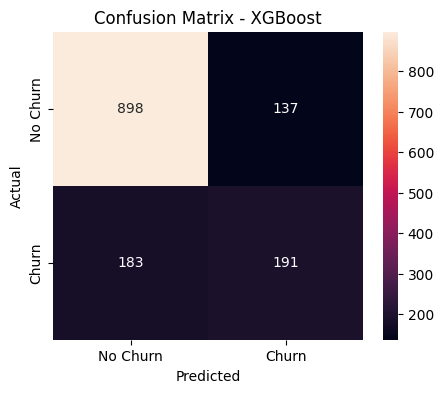

In [66]:
plot_confusion_matrix(y_test, y_test_pred_xgb, "XGBoost")

## Model 5 – CatBoost

<div dir="rtl" style="text-align: right;">

CatBoost הוא גם מודל ממשפחת Gradient Boosting, בדומה ל־XGBoost.

גם הוא בונה עצים אחד אחרי השני:

עץ ראשון עושה תחזיות

עץ שני מתקן טעויות

עץ שלישי מתקן עוד טעויות
...

אבל היתרון המיוחד של CatBoost הוא שהוא נבנה כדי לעבוד טוב במיוחד עם עמודות קטגוריאליות.

In [67]:
from catboost import CatBoostClassifier

<div dir="rtl" style="text-align: right;">

יצירת Pipeline ל־CatBoost

CatBoostClassifier(...) - זה המודל שלנו לסיווג. במקרה שלנו הוא חוזה האם הלקוח נטש=1 אם הלקוח לא נטש = 0 

random_seed=42 - המטרה היא לקבל תוצאות יציבות בהרצות חוזרות.

verbose=0 - המודל בדרך כלל מדפיס הרבה שורות בזמן האימון. כאשר כותבים שורה זו בעצם אומרים לו לא להדפיס את כל תהליך האימון

allow_writing_files=False - המודל לפעמים יוצר תיקייה בשם: catboost_info בתיקיית העבודה. השורה הזאת מונעת את יצירת התיקייה


In [68]:
catboost_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        random_seed=42,
        verbose=0,
        allow_writing_files=False
    ))
])

<div dir="rtl" style="text-align: right;">
 
 אימון המודל 

1. הנתונים עוברים preprocessing.
2. הקטגוריות עוברות One-Hot Encoding.
3. העמודות המספריות עוברות scaling.
4. CatBoost בונה סדרה של עצים.
5. כל עץ חדש מנסה לשפר את הטעויות של הקודמים.

In [69]:
catboost_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<div dir="rtl" style="text-align: right;">

תחזית

In [73]:
y_train_pred_cat = catboost_pipeline.predict(x_train)
y_test_pred_cat = catboost_pipeline.predict(x_test)

print(classification_report(y_test, y_test_pred_cat))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



<div dir="rtl" style="text-align: right;">

הסתברות לנטישה

In [74]:
y_test_proba_cat = catboost_pipeline.predict_proba(x_test)[:, 1]
print(classification_report(y_test, y_test_pred_cat))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



חישוב מדדים

In [75]:
catboost_results = {
    "Model": "CatBoost",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_cat),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_cat),
    "Precision": precision_score(y_test, y_test_pred_cat),
    "Recall": recall_score(y_test, y_test_pred_cat),
    "F1 Score": f1_score(y_test, y_test_pred_cat),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_cat)
}

catboost_results

{'Model': 'CatBoost',
 'Train Accuracy': 0.8743343982960596,
 'Test Accuracy': 0.7927608232789212,
 'Precision': 0.6348684210526315,
 'Recall': 0.516042780748663,
 'F1 Score': 0.5693215339233039,
 'ROC-AUC': 0.8388824304425326}

Classification Report

In [76]:
print(classification_report(y_test, y_test_pred_cat))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



Confusion Matrix

In [77]:
catboost_confusion_matrix = confusion_matrix(y_test, y_test_pred_cat)

catboost_confusion_matrix

array([[924, 111],
       [181, 193]])

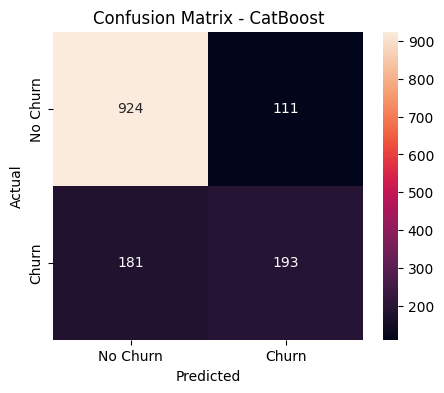

In [78]:
plot_confusion_matrix(y_test, y_test_pred_cat, "CatBoost")

### Model 5 – CatBoost

CatBoost is a gradient boosting model based on decision trees.

Like XGBoost, it builds trees sequentially, where each new tree tries to correct the errors of the previous trees.

CatBoost is especially useful for datasets with many categorical features. In this baseline experiment, the same preprocessing pipeline was used for consistency across all models.

The model was evaluated using train and test accuracy, precision, recall, F1-score, ROC-AUC, classification report, and confusion matrix.

## Model 6 – k-Nearest Neighbors, k-NN

<div dir="rtl" style="text-align: right;">

k-NN הוא מודל שמסווג לקוח לפי הלקוחות הכי דומים לו.

הרעיון: כדי לחזות אם לקוח חדש ינטוש, המודל מסתכל על הלקוחות הכי קרובים אליו בדאטה, ובודק מה רובם עשו.

לדוגמה, אם נגדיר: k = 5 , אז עבור כל לקוח, המודל יחפש את 5 הלקוחות הכי דומים לו.

למה k-NN חייב Scaling? 

זה מודל שמבוסס על מרחקים. למשל, הוא מחשב מי הלקוחות הכי קרובים לפי מאפיינים כמו:

tenure, MonthlyCharges, TotalCharges

אם לא נעשה scaling, עמודה כמו TotalCharges, שיכולה להגיע לאלפים, תשפיע הרבה יותר מעמודה כמו tenure, שנעה בערך בין 0 ל־72.

לכן עבור k-NN, StandardScaler מאוד חשוב.

In [84]:
from sklearn.neighbors import KNeighborsClassifier

In [85]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

In [86]:
knn_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [87]:
y_train_pred_knn = knn_pipeline.predict(x_train)
y_test_pred_knn = knn_pipeline.predict(x_test)

In [89]:
y_test_proba_knn = knn_pipeline.predict_proba(x_test)[:, 1]

In [90]:
knn_results = {
    "Model": "k-NN",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_knn),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_knn),
    "Precision": precision_score(y_test, y_test_pred_knn),
    "Recall": recall_score(y_test, y_test_pred_knn),
    "F1 Score": f1_score(y_test, y_test_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_knn)
}

knn_results

{'Model': 'k-NN',
 'Train Accuracy': 0.8359957401490948,
 'Test Accuracy': 0.758694109297374,
 'Precision': 0.5442708333333334,
 'Recall': 0.5588235294117647,
 'F1 Score': 0.5514511873350924,
 'ROC-AUC': 0.7851752822341056}

In [91]:
print(classification_report(y_test, y_test_pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1035
           1       0.54      0.56      0.55       374

    accuracy                           0.76      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409



In [92]:
knn_confusion_matrix = confusion_matrix(y_test, y_test_pred_knn)

knn_confusion_matrix

array([[860, 175],
       [165, 209]])

### Model 6 – k-Nearest Neighbors

k-Nearest Neighbors is a distance-based classification model.

For each customer, the model looks for the k most similar customers in the training data and predicts the majority class among those neighbors.

In this baseline model, the default value k=5 was used.

Since k-NN is based on distances, scaling numerical features is especially important. Therefore, the model was trained using the same preprocessing pipeline that includes StandardScaler for numerical features and OneHotEncoder for categorical features.

The model was evaluated using train and test accuracy, precision, recall, F1-score, ROC-AUC, classification report, and confusion matrix.

<div dir="rtl" style="text-align: right;">
למה לצפות מ־k-NN?

k-NN יכול לעבוד טוב, אבל בדאטה עם הרבה עמודות אחרי One-Hot Encoding הוא לפעמים פחות חזק.

למה?
כי אחרי encoding יש לנו הרבה features, ואז קשה יותר למדוד “מרחק אמיתי” בין לקוחות. זה נקרא לפעמים בעיית ממדיות גבוהה.

בנוסף, k-NN יכול להיות איטי יותר בזמן חיזוי, כי עבור כל לקוח חדש הוא צריך להשוות אותו ללקוחות האימון.

לכן הוא מודל טוב ללמידה ולהשוואה, אבל לא תמיד יהיה הכי טוב לבעיה עסקית כמו Churn.


## Step 4 – Model Evaluation

In [93]:
comparison_df = pd.DataFrame([
    log_reg_results,
    decision_tree_results,
    random_forest_results,
    xgboost_results,
    catboost_results,
    knn_results
])

comparison_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805999,0.805536,0.657233,0.558824,0.604046,0.841957
1,Decision Tree,0.998048,0.728176,0.488251,0.500000,0.494055,0.655072
2,Random Forest,0.998048,0.785664,0.623288,0.486631,0.546547,0.818691
3,XGBoost,0.935747,0.772889,0.582317,0.510695,0.544160,0.815194
4,CatBoost,0.874334,0.792761,0.634868,0.516043,0.569322,0.838882
5,k-NN,0.835996,0.758694,0.544271,0.558824,0.551451,0.785175


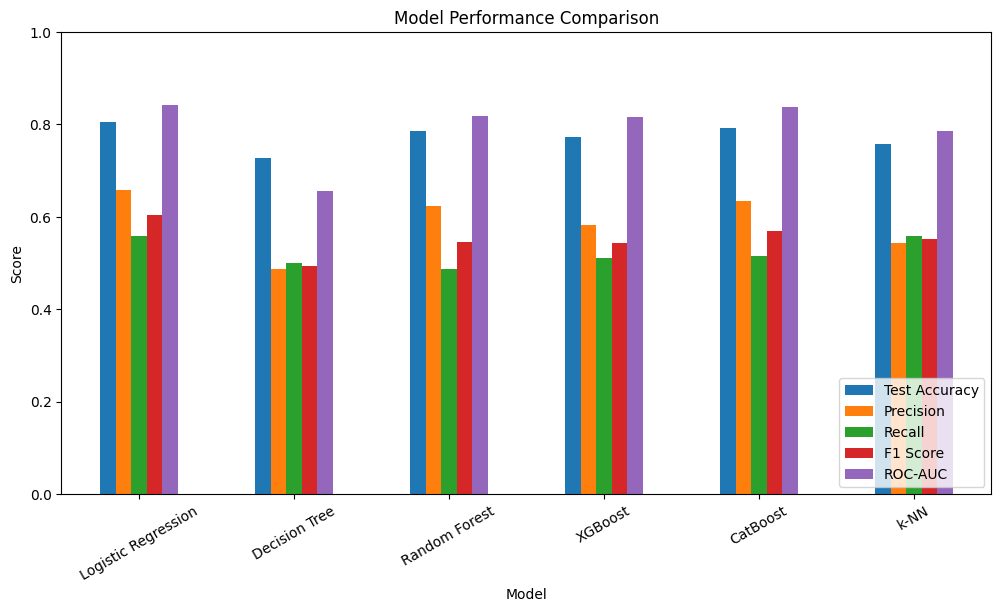

In [94]:
comparison_df.set_index("Model")[
    ["Test Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

In [95]:
comparison_df["Overfitting Gap"] = (
    comparison_df["Train Accuracy"] - comparison_df["Test Accuracy"]
)

comparison_df[["Model", "Train Accuracy", "Test Accuracy", "Overfitting Gap"]]

,Model,Train Accuracy,Test Accuracy,Overfitting Gap
0,Logistic Regression,0.805999,0.805536,0.000463
1,Decision Tree,0.998048,0.728176,0.269872
2,Random Forest,0.998048,0.785664,0.212384
3,XGBoost,0.935747,0.772889,0.162859
4,CatBoost,0.874334,0.792761,0.081574
5,k-NN,0.835996,0.758694,0.077302


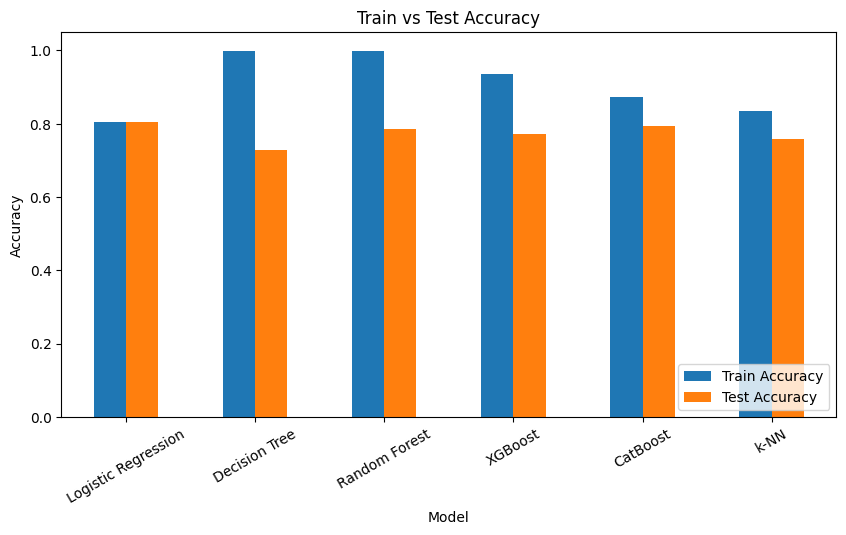

In [96]:
comparison_df.set_index("Model")[
    ["Train Accuracy", "Test Accuracy"]
].plot(kind="bar", figsize=(10, 5))

plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()

## Step 4 – Model Evaluation

In this step, all baseline models are compared using Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC Curve, and ROC-AUC.

<div dir="rtl" style="text-align: right;">

F1 Score → מי הכי מאזן בין Precision ל־Recall

ROC-AUC → מי הכי טוב בהפרדה בין נוטשים ללא־נוטשים

In [97]:
comparison_df_sorted = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_df_sorted

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting Gap
0,Logistic Regression,0.805999,0.805536,0.657233,0.558824,0.604046,0.841957,0.000463
4,CatBoost,0.874334,0.792761,0.634868,0.516043,0.569322,0.838882,0.081574
5,k-NN,0.835996,0.758694,0.544271,0.558824,0.551451,0.785175,0.077302
2,Random Forest,0.998048,0.785664,0.623288,0.486631,0.546547,0.818691,0.212384
3,XGBoost,0.935747,0.772889,0.582317,0.510695,0.544160,0.815194,0.162859
1,Decision Tree,0.998048,0.728176,0.488251,0.500000,0.494055,0.655072,0.269872


In [98]:
comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting Gap
0,Logistic Regression,0.805999,0.805536,0.657233,0.558824,0.604046,0.841957,0.000463
4,CatBoost,0.874334,0.792761,0.634868,0.516043,0.569322,0.838882,0.081574
2,Random Forest,0.998048,0.785664,0.623288,0.486631,0.546547,0.818691,0.212384
3,XGBoost,0.935747,0.772889,0.582317,0.510695,0.544160,0.815194,0.162859
5,k-NN,0.835996,0.758694,0.544271,0.558824,0.551451,0.785175,0.077302
1,Decision Tree,0.998048,0.728176,0.488251,0.500000,0.494055,0.655072,0.269872


גרף השוואת מדדים



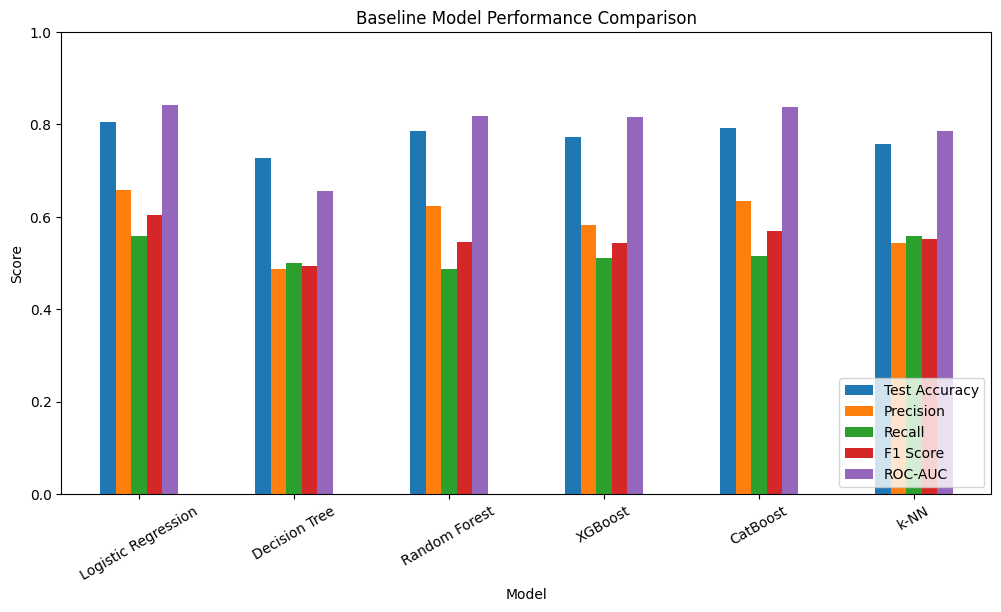

In [99]:
comparison_df.set_index("Model")[
    ["Test Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

 Confusion Matrix לכל המודלים

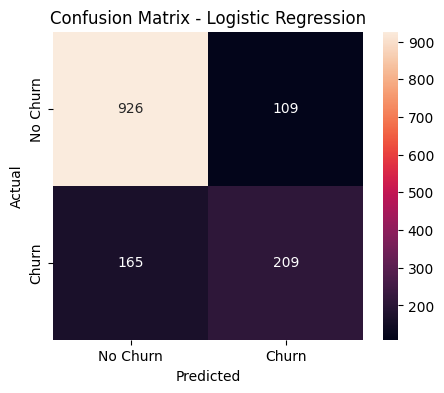

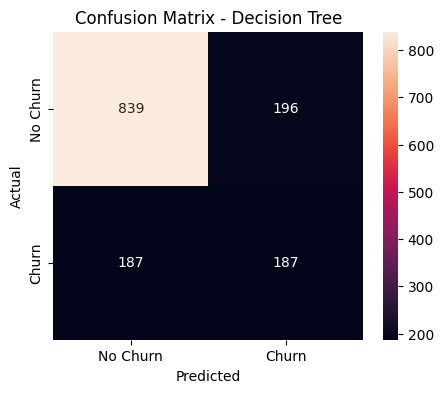

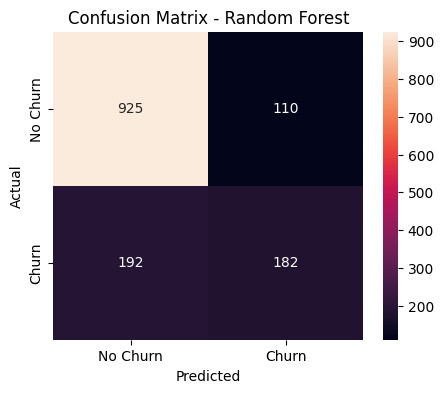

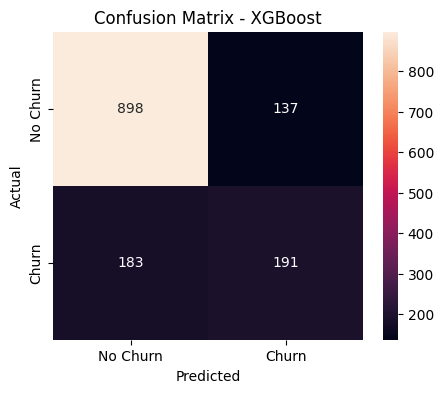

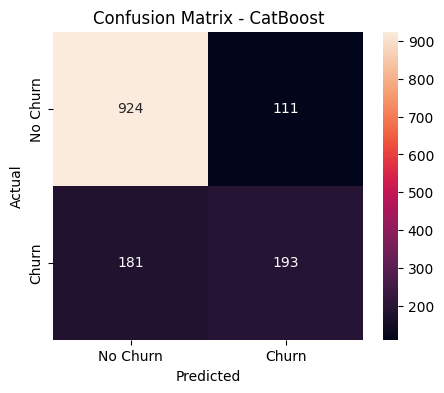

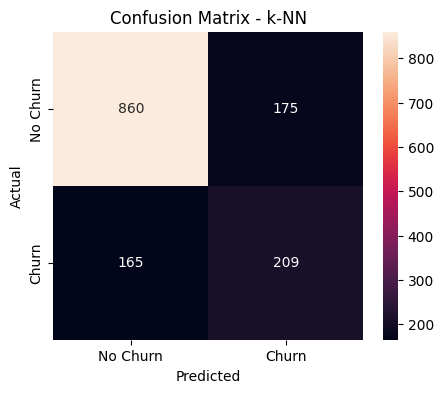

In [100]:
model_predictions = {
    "Logistic Regression": y_test_pred_log,
    "Decision Tree": y_test_pred_tree,
    "Random Forest": y_test_pred_forest,
    "XGBoost": y_test_pred_xgb,
    "CatBoost": y_test_pred_cat,
    "k-NN": y_test_pred_knn
}

for model_name, y_pred in model_predictions.items():
    plot_confusion_matrix(y_test, y_pred, model_name)

ROC Curve

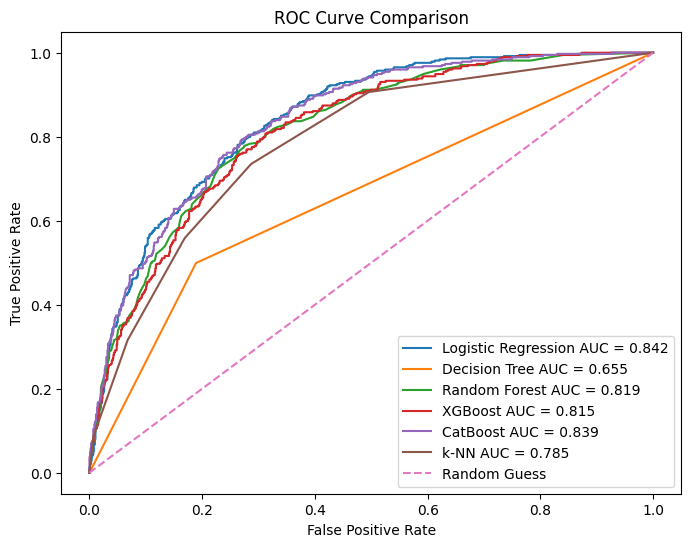

In [101]:
from sklearn.metrics import roc_curve, auc

model_probabilities = {
    "Logistic Regression": y_test_proba_log,
    "Decision Tree": y_test_proba_tree,
    "Random Forest": y_test_proba_forest,
    "XGBoost": y_test_proba_xgb,
    "CatBoost": y_test_proba_cat,
    "k-NN": y_test_proba_knn
}

plt.figure(figsize=(8, 6))

for model_name, y_proba in model_probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    model_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {model_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Step 5 – Overfitting Analysis

In [102]:
comparison_df["Overfitting Gap"] = (
    comparison_df["Train Accuracy"] - comparison_df["Test Accuracy"]
)

comparison_df[[
    "Model",
    "Train Accuracy",
    "Test Accuracy",
    "Overfitting Gap"
]].sort_values(by="Overfitting Gap", ascending=False)

,Model,Train Accuracy,Test Accuracy,Overfitting Gap
1,Decision Tree,0.998048,0.728176,0.269872
2,Random Forest,0.998048,0.785664,0.212384
3,XGBoost,0.935747,0.772889,0.162859
4,CatBoost,0.874334,0.792761,0.081574
5,k-NN,0.835996,0.758694,0.077302
0,Logistic Regression,0.805999,0.805536,0.000463


גרף Train מול Test

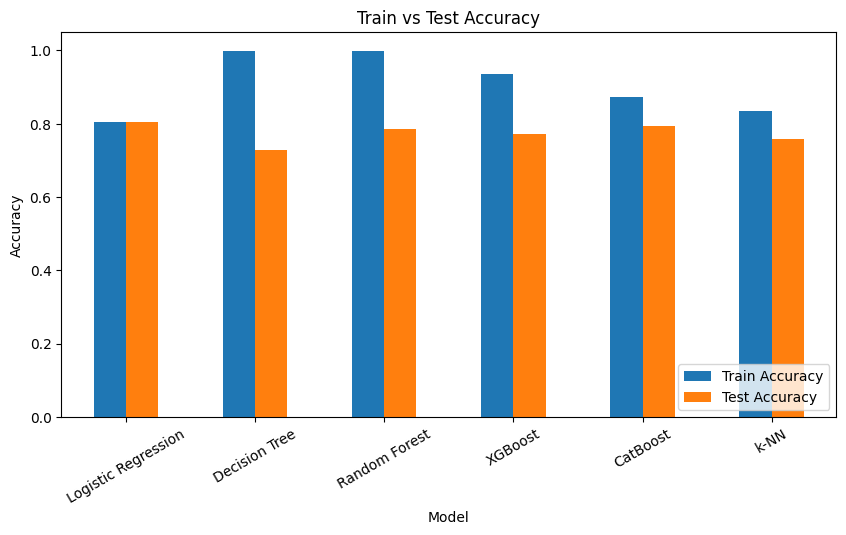

In [103]:
comparison_df.set_index("Model")[
    ["Train Accuracy", "Test Accuracy"]
].plot(kind="bar", figsize=(10, 5))

plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()

גרף רק של Overfitting Gap

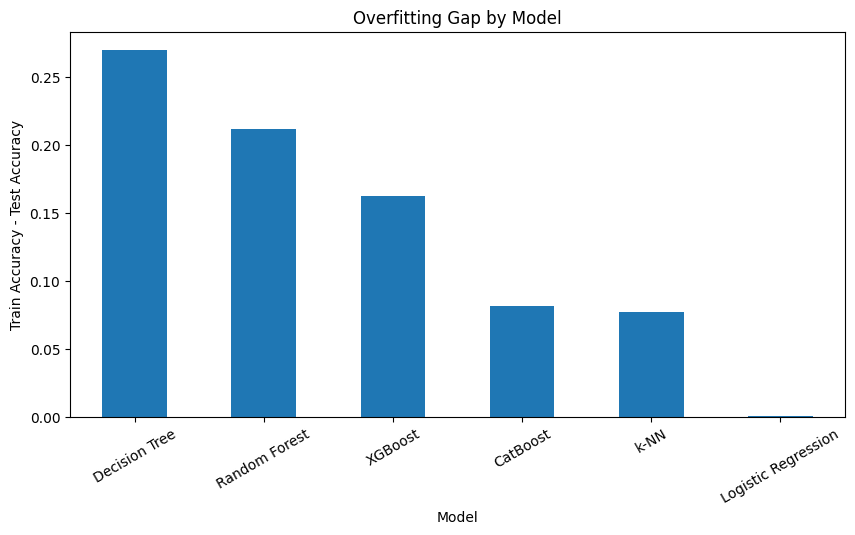

In [104]:
comparison_df.sort_values(
    by="Overfitting Gap",
    ascending=False
).plot(
    x="Model",
    y="Overfitting Gap",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Overfitting Gap by Model")
plt.ylabel("Train Accuracy - Test Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.show()

### step 4 + 5 Summary

Among the baseline models, Logistic Regression achieved the strongest overall performance.  
It had the highest F1-score and ROC-AUC, while showing almost no overfitting.

CatBoost was the second strongest baseline model, with ROC-AUC very close to Logistic Regression, but with a slightly lower F1-score and some overfitting.

Decision Tree showed severe overfitting, with almost perfect train accuracy but much lower test accuracy.

Random Forest also showed clear overfitting, although it performed better than a single Decision Tree.

XGBoost also showed some overfitting and did not outperform Logistic Regression in the baseline setup.

k-NN achieved recall similar to Logistic Regression, but its precision was lower, meaning it produced more false positives.

Overall, Logistic Regression is currently the best baseline model.  
However, tree-based models may improve after hyperparameter tuning.

# Step 6 – Model Tuning

## Logistic Regression Tuning
<div dir="rtl" style="text-align: right;">

המטרה עכשיו היא לבדוק האם אפשר לשפר את המודל הבסיסי של Logistic Regression בעזרת שינוי פרמטרים.

ב־baseline השתמשנו במודל עם הגדרות כמעט רגילות. עכשיו ננסה כמה אפשרויות ונבחר את הטובה ביותר בעזרת GridSearchCV.

GridSearchCV עושה שני דברים:

- מנסה כמה שילובים של hyperparameters.
- בודק כל שילוב בעזרת Cross Validation.

כלומר במקום שאנחנו ננחש ידנית איזה ערכים טובים, הוא בודק בשבילנו.

לפי ההנחיה: C, penalty

מה זה C?  שולט על עוצמת ה־regularization. Regularization היא דרך למנוע מהמודל להיות מורכב מדי.


- C קטן  → regularization חזקה יותר
- C גדול → regularization חלשה יותר

C = 0.01 : המודל יהיה יותר “מרוסן”.

C = 100 : המודל יהיה פחות מרוסן וינסה להתאים את עצמו יותר לנתונים.

מה זה penalty? penalty אומר באיזה סוג regularization להשתמש.

נבדוק:

- l1 - יכול לאפס חלק מהמשתנים, ולכן לפעמים עוזר לבחור features חשובים.

- l2 - האפשרות הנפוצה יותר. מקטינה משקלים אבל בדרך כלל לא מאפסת אותם לגמרי.

In [105]:
from sklearn.model_selection import GridSearchCV

log_reg_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=42
    ))
])

<div dir="rtl" style="text-align: right;">

למה solver="liblinear"? כי אנחנו רוצים לבדוק גם: penalty="l1" וגם: penalty="l2"

לא כל solver תומך ב־l1. liblinear מתאים במקרה שלנו כי הוא תומך בשניהם.

הגדרת רשת הפרמטרים

In [106]:
log_reg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

<div dir="rtl" style="text-align: right;">

למה יש model__?

כי בתוך ה־Pipeline קראנו לשלב של המודל:

("model", LogisticRegression(...))

אז כדי להגיד ל־GridSearchCV לשנות פרמטר של המודל, כותבים:

שם השלב בתוך ה-Pipeline + __ + שם הפרמטר

כלומר:

model__C

model__penalty

<div dir="rtl" style="text-align: right;">

יצירת GridSearchCV

In [107]:
log_reg_grid_search = GridSearchCV(
    estimator=log_reg_tuning_pipeline,
    param_grid=log_reg_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

<div dir="rtl" style="text-align: right;">

מה אומר כל חלק?

estimator=log_reg_tuning_pipeline - זה המודל שאנחנו רוצים לכוונן.

param_grid=log_reg_param_grid - אלה כל שילובי הפרמטרים שנרצה לבדוק.

cv=5 - הנתונים יחולקו ל־5 חלקים. כל פעם המודל יתאמן על 4 חלקים וייבדק על חלק אחד.

scoring="f1" - אנחנו בוחרים את המודל לפי F1 Score.

למה לא Accuracy? כי יש לנו class imbalance, ולכן Accuracy לבד עלול להטעות.

n_jobs=-1 - להשתמש בכל ליבות המעבד כדי להריץ מהר יותר.

<div dir="rtl" style="text-align: right;">

הרצת החיפוש

In [108]:
log_reg_grid_search.fit(x_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


<div dir="rtl" style="text-align: right;">

לראות את הפרמטרים הכי טובים

In [109]:
print("Best parameters:")
print(log_reg_grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(log_reg_grid_search.best_score_)

Best parameters:
{'model__C': 100, 'model__penalty': 'l2'}

Best cross-validation F1 score:
0.599371387712228


<div dir="rtl" style="text-align: right;">

שמירת המודל הכי טוב 

In [110]:
best_log_reg_model = log_reg_grid_search.best_estimator_

חיזוי עם המודל המכוונן 

In [111]:
y_train_pred_log_tuned = best_log_reg_model.predict(x_train)
y_test_pred_log_tuned = best_log_reg_model.predict(x_test)

y_test_proba_log_tuned = best_log_reg_model.predict_proba(x_test)[:, 1]

חישוב תוצאות המודל המכוון

In [112]:
log_reg_tuned_results = {
    "Model": "Logistic Regression Tuned",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_log_tuned),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_log_tuned),
    "Precision": precision_score(y_test, y_test_pred_log_tuned),
    "Recall": recall_score(y_test, y_test_pred_log_tuned),
    "F1 Score": f1_score(y_test, y_test_pred_log_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_log_tuned)
}

log_reg_tuned_results

{'Model': 'Logistic Regression Tuned',
 'Train Accuracy': 0.8065317713880015,
 'Test Accuracy': 0.801277501774308,
 'Precision': 0.6477987421383647,
 'Recall': 0.5508021390374331,
 'F1 Score': 0.5953757225433526,
 'ROC-AUC': 0.8408432147562582}

classification report

In [113]:
print(classification_report(y_test, y_test_pred_log_tuned))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



Confusion Matrix

In [115]:
log_reg_tuned_confusion_matrix = confusion_matrix(y_test, y_test_pred_log_tuned)
log_reg_tuned_confusion_matrix 

array([[923, 112],
       [168, 206]])

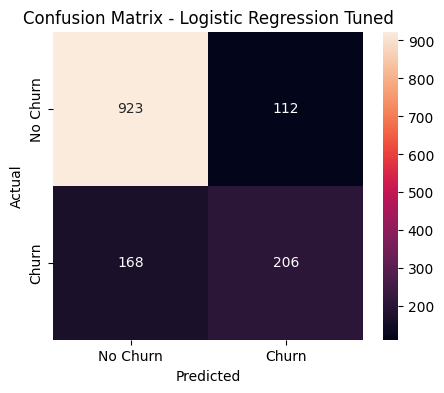

In [116]:
plot_confusion_matrix(
    y_test,
    y_test_pred_log_tuned,
    "Logistic Regression Tuned"
)

השוואה מול Logistic Regression baseline

In [117]:
log_reg_comparison = pd.DataFrame([
    log_reg_results,
    log_reg_tuned_results
])

log_reg_comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805999,0.805536,0.657233,0.558824,0.604046,0.841957
1,Logistic Regression Tuned,0.806532,0.801278,0.647799,0.550802,0.595376,0.840843


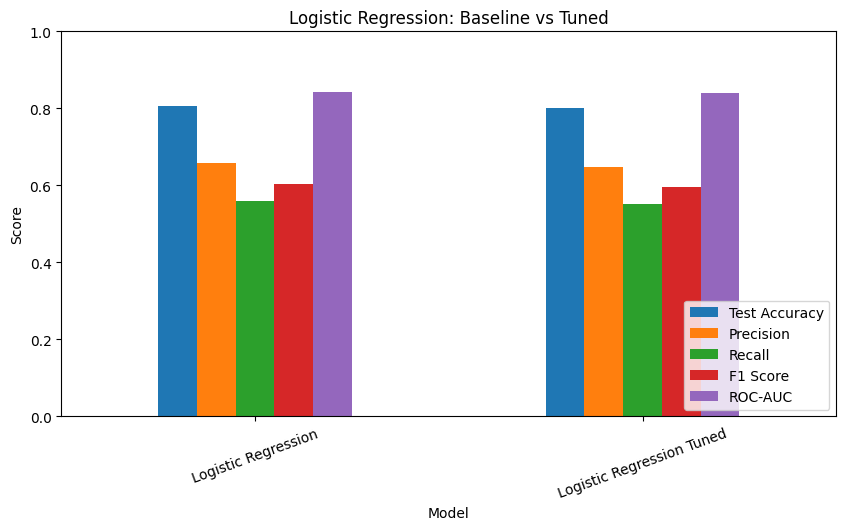

In [118]:
log_reg_comparison.set_index("Model")[
    ["Test Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(10, 5))

plt.title("Logistic Regression: Baseline vs Tuned")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()